# Day 7: Model Evaluation & Imbalance Handling

**Dataset:** Titanic cleaned (from Day 2)
**Target:** `survived` (binary, 61% died / 39% survived)
**Goal:** Precision/Recall/F1/ROC-AUC/PR-AUC, SMOTE, class-weighting

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load cleaned data
df = pd.read_csv('../data/titanic_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (891, 19)


In [5]:
# 1. PREPARE FEATURES & TARGET
numeric_features = ['age', 'sibsp', 'parch', 'family_size', 'fare_per_person', 'pclass', 'is_alone']
cat_features = ['sex', 'embarked', 'deck', 'who', 'age_bin']

df_encoded = df.copy()
for col in cat_features:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))

encoded_features = [c + '_encoded' for c in cat_features]
all_features = numeric_features + encoded_features

X = df_encoded[all_features]
y = df_encoded['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance: {y_test.value_counts().to_dict()}")

Train: (712, 12), Test: (179, 12)
Train class balance: {0: 439, 1: 273}
Test class balance: {0: 110, 1: 69}


In [6]:
# 2. BASELINE: LOGISTIC REGRESSION with class_weight='balanced'
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (class_weight='balanced') ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_lr):.4f}")
print(f"F1 (macro):  {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Died', 'Survived']))

=== Logistic Regression (class_weight='balanced') ===
Accuracy:    0.7821
ROC-AUC:     0.8543
PR-AUC:      0.8003
F1 (macro):  0.7729
              precision    recall  f1-score   support

        Died       0.84      0.80      0.82       110
    Survived       0.70      0.75      0.73        69

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.79      0.78      0.78       179



In [7]:
# 3. BASELINE: RANDOM FOREST with class_weight='balanced'
rf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (class_weight='balanced') ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_rf):.4f}")
print(f"F1 (macro):  {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Died', 'Survived']))

=== Random Forest (class_weight='balanced') ===
Accuracy:    0.7933
ROC-AUC:     0.8428
PR-AUC:      0.8268
F1 (macro):  0.7846
              precision    recall  f1-score   support

        Died       0.85      0.81      0.83       110
    Survived       0.72      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179



In [8]:
# 4. SMOTE OVERSAMPLING
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original train shape: {X_train.shape}")
print(f"SMOTE train shape:    {X_train_smote.shape}")
print(f"Original class dist:  {pd.Series(y_train).value_counts().to_dict()}")
print(f"SMOTE class dist:     {pd.Series(y_train_smote).value_counts().to_dict()}")

# Train Logistic Regression on SMOTE data
lr_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test)
y_proba_lr_smote = lr_smote.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression + SMOTE ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_lr_smote):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_lr_smote):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_lr_smote):.4f}")
print(f"F1 (macro):  {f1_score(y_test, y_pred_lr_smote, average='macro'):.4f}")
print(classification_report(y_test, y_pred_lr_smote, target_names=['Died', 'Survived']))

Original train shape: (712, 12)
SMOTE train shape:    (878, 12)
Original class dist:  {0: 439, 1: 273}
SMOTE class dist:     {1: 439, 0: 439}

=== Logistic Regression + SMOTE ===
Accuracy:    0.8045
ROC-AUC:     0.8574
PR-AUC:      0.7981
F1 (macro):  0.7931
              precision    recall  f1-score   support

        Died       0.84      0.85      0.84       110
    Survived       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [9]:
# 5. SMOTE + RANDOM FOREST
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

print("=== Random Forest + SMOTE ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_rf_smote):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_rf_smote):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_rf_smote):.4f}")
print(f"F1 (macro):  {f1_score(y_test, y_pred_rf_smote, average='macro'):.4f}")
print(classification_report(y_test, y_pred_rf_smote, target_names=['Died', 'Survived']))

=== Random Forest + SMOTE ===
Accuracy:    0.7765
ROC-AUC:     0.8468
PR-AUC:      0.8177
F1 (macro):  0.7654
              precision    recall  f1-score   support

        Died       0.82      0.81      0.82       110
    Survived       0.70      0.72      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



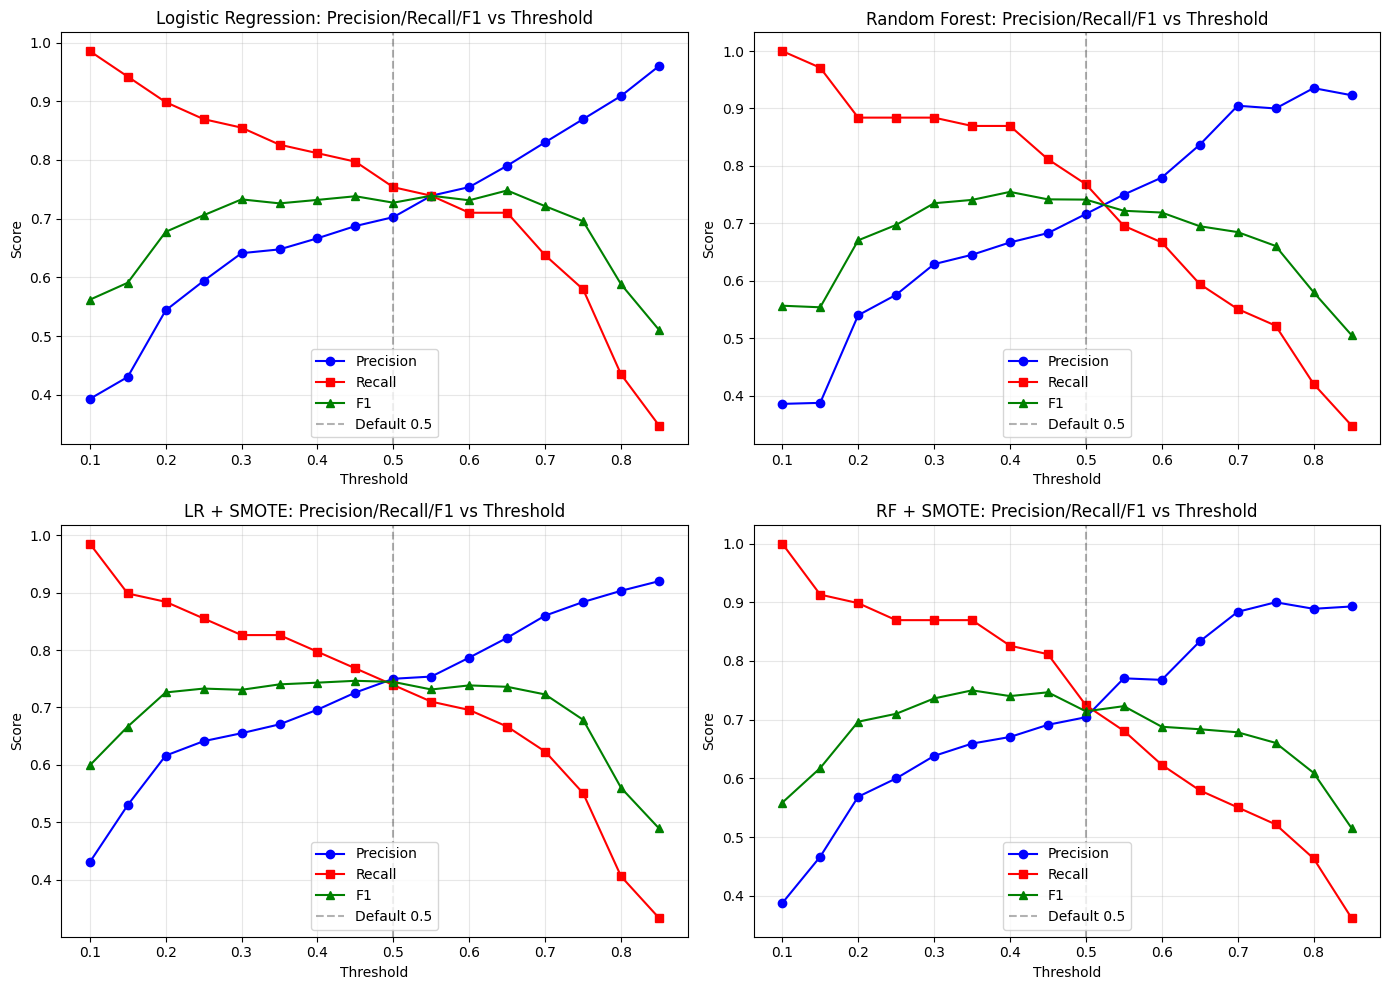

In [10]:
# 6. THRESHOLD TUNING: Precision-Recall Trade-off
def evaluate_thresholds(y_true, y_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    results = []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        results.append({
            'threshold': thresh,
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'accuracy': accuracy_score(y_true, y_pred)
        })
    return pd.DataFrame(results)

thresholds = np.arange(0.1, 0.9, 0.05)
lr_thresh = evaluate_thresholds(y_test, y_proba_lr, thresholds)
rf_thresh = evaluate_thresholds(y_test, y_proba_rf, thresholds)
lr_smote_thresh = evaluate_thresholds(y_test, y_proba_lr_smote, thresholds)
rf_smote_thresh = evaluate_thresholds(y_test, y_proba_rf_smote, thresholds)

# Plot Precision-Recall vs Threshold
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models_data = [
    (lr_thresh, 'Logistic Regression'),
    (rf_thresh, 'Random Forest'),
    (lr_smote_thresh, 'LR + SMOTE'),
    (rf_smote_thresh, 'RF + SMOTE')
]

for i, (df_thresh, name) in enumerate(models_data):
    ax = axes[i // 2, i % 2]
    ax.plot(df_thresh['threshold'], df_thresh['precision'], 'b-', label='Precision', marker='o')
    ax.plot(df_thresh['threshold'], df_thresh['recall'], 'r-', label='Recall', marker='s')
    ax.plot(df_thresh['threshold'], df_thresh['f1'], 'g-', label='F1', marker='^')
    ax.axvline(0.5, color='k', linestyle='--', alpha=0.3, label='Default 0.5')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{name}: Precision/Recall/F1 vs Threshold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# 7. PR-AUC vs ROC-AUC COMPARISON
models_proba = {
    'LR (balanced)': y_proba_lr,
    'RF (balanced)': y_proba_rf,
    'LR + SMOTE': y_proba_lr_smote,
    'RF + SMOTE': y_proba_rf_smote
}

print("=== PR-AUC vs ROC-AUC ===")
for name, y_proba in models_proba.items():
    roc = roc_auc_score(y_test, y_proba)
    pr = average_precision_score(y_test, y_proba)
    print(f"{name:20s} ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}  Diff: {roc-pr:.4f}")

=== PR-AUC vs ROC-AUC ===
LR (balanced)        ROC-AUC: 0.8543  PR-AUC: 0.8003  Diff: 0.0539
RF (balanced)        ROC-AUC: 0.8428  PR-AUC: 0.8268  Diff: 0.0159
LR + SMOTE           ROC-AUC: 0.8574  PR-AUC: 0.7981  Diff: 0.0593
RF + SMOTE           ROC-AUC: 0.8468  PR-AUC: 0.8177  Diff: 0.0291


In [12]:
# 8. CROSS-VALIDATION WITH STRATIFIED K-FOLD
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'LR (balanced)': Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
    'RF (balanced)': RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'LR + SMOTE': ImbPipeline([('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'RF + SMOTE': ImbPipeline([('smote', SMOTE(random_state=42)), ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1))])
}

print("=== 5-Fold Stratified CV Results ===")
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name:20s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

=== 5-Fold Stratified CV Results ===
LR (balanced)        ROC-AUC: 0.8542 (+/- 0.0277)
RF (balanced)        ROC-AUC: 0.8795 (+/- 0.0229)
LR + SMOTE           ROC-AUC: 0.8559 (+/- 0.0294)
RF + SMOTE           ROC-AUC: 0.8816 (+/- 0.0221)


## Summary Notes

- Best approach for this imbalance level: 
- When PR-AUC >> ROC-AUC difference: 
- SMOTE helped/hurt: 
- Optimal threshold for deployment: 